In [12]:
import json
import os

import numpy as np
import pandas as pd

#dir = '../large_files/new_beam_matching_experiment_1nrec'
dir = '../data/results/experiments/new_beam_matching_experiment_10'

data_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

data_df['n_best_pcis'] = data_df['n_best_pcis'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')
data_df['n_best_beams'] = data_df['n_best_beams'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')

data_df

,errors,complexity,run,n_best_pcis,n_best_beams
0,2.221874,3373656.0,0.0,all,all
1,3.023250,3373656.0,0.0,all,all
2,0.274133,3373656.0,0.0,all,all
3,9.892799,3373656.0,0.0,all,all
4,6.301775,3373656.0,0.0,all,all
...,...,...,...,...,...
759955,0.040098,3253800.0,9.0,29,all
759956,0.323448,3253800.0,9.0,29,all
759957,7.942833,3253800.0,9.0,29,all
759958,0.398853,3253800.0,9.0,29,all


In [13]:
res = []
for group, data in data_df.groupby(['n_best_pcis', 'n_best_beams']):
    errors = data.groupby('run')['errors'].mean().values
    complexity = data.groupby('run')['complexity'].mean().values
    for i in range(errors.shape[0]):
        res.append((group[0], group[1], errors[i], complexity[i]))

df = pd.DataFrame(res, columns=['n_best_pcis', 'n_best_beams', 'errors', 'complexity'])

df

,n_best_pcis,n_best_beams,errors,complexity
0,1,all,26.426402,813924.0
1,1,all,26.096326,804540.0
2,1,all,25.971851,811164.0
3,1,all,25.122626,820548.0
4,1,all,26.830656,811164.0
...,...,...,...,...
295,all,all,2.710682,3373084.0
296,all,all,2.734951,3373084.0
297,all,all,2.704377,3382236.0
298,all,all,2.772349,3297580.0


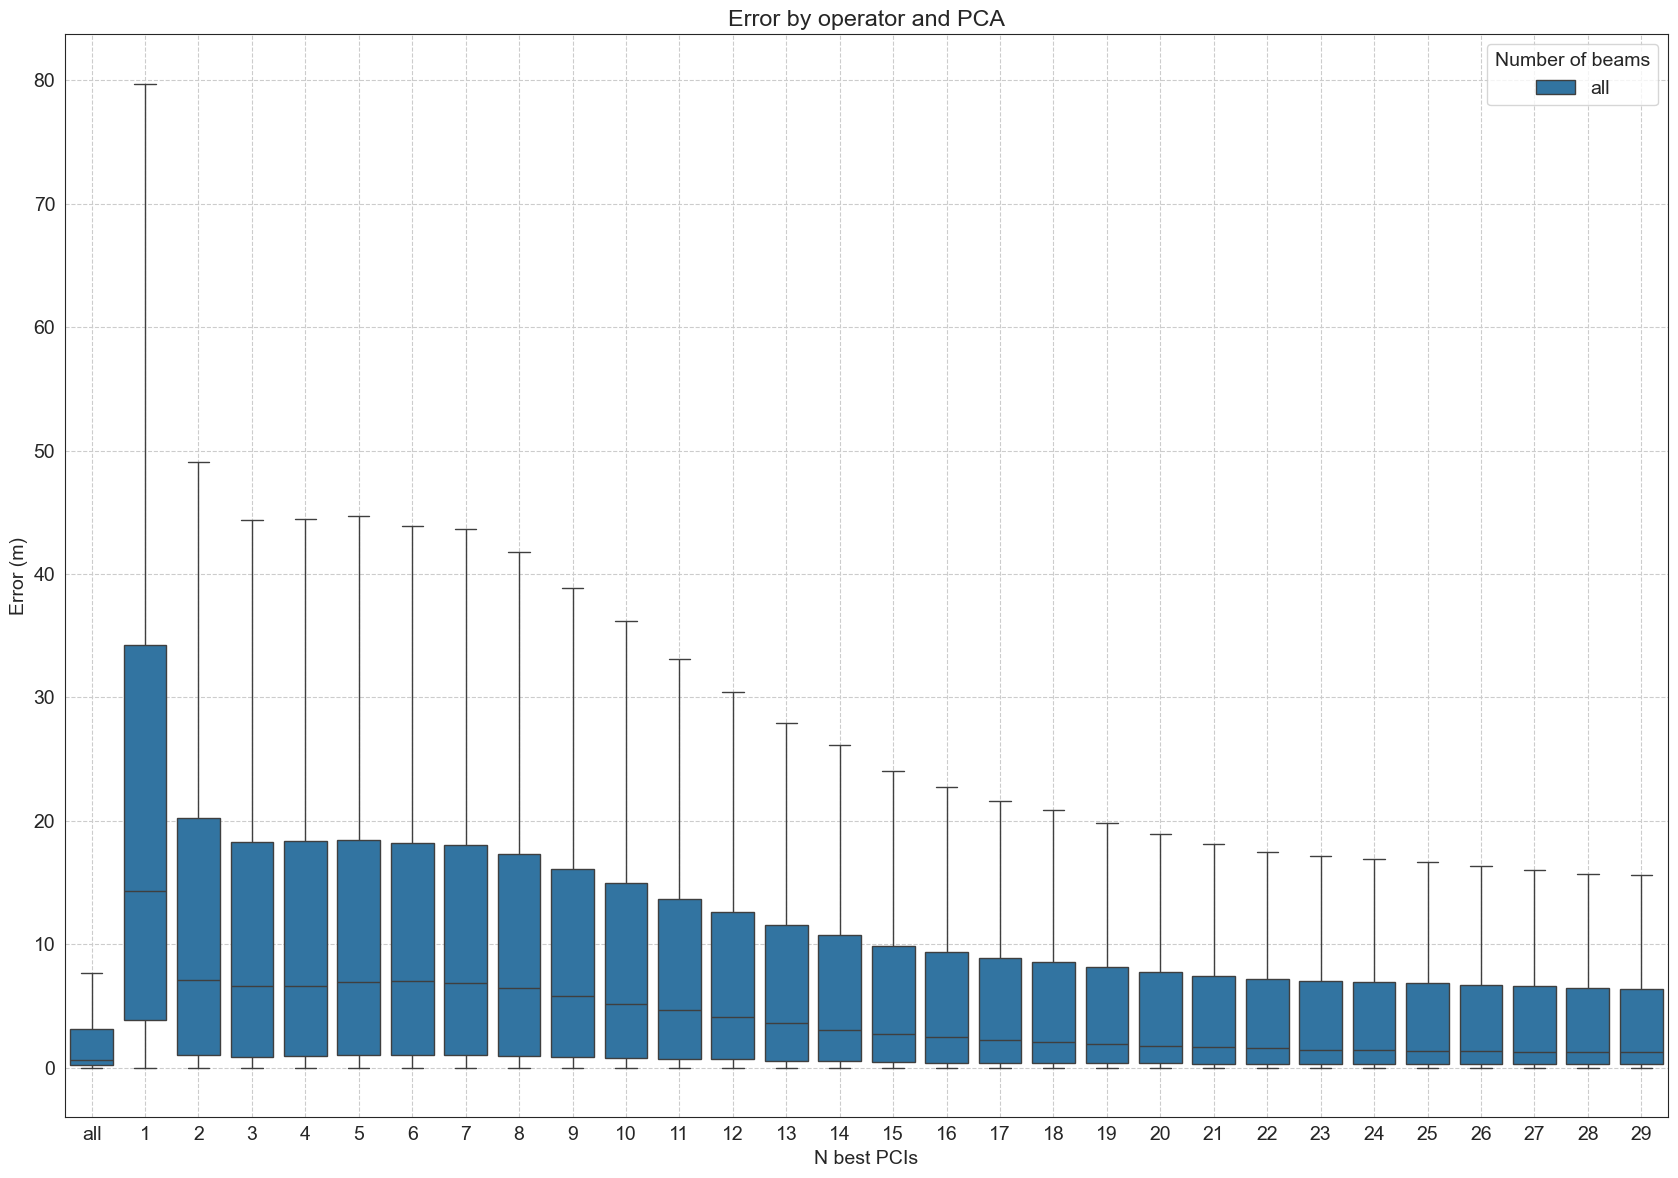

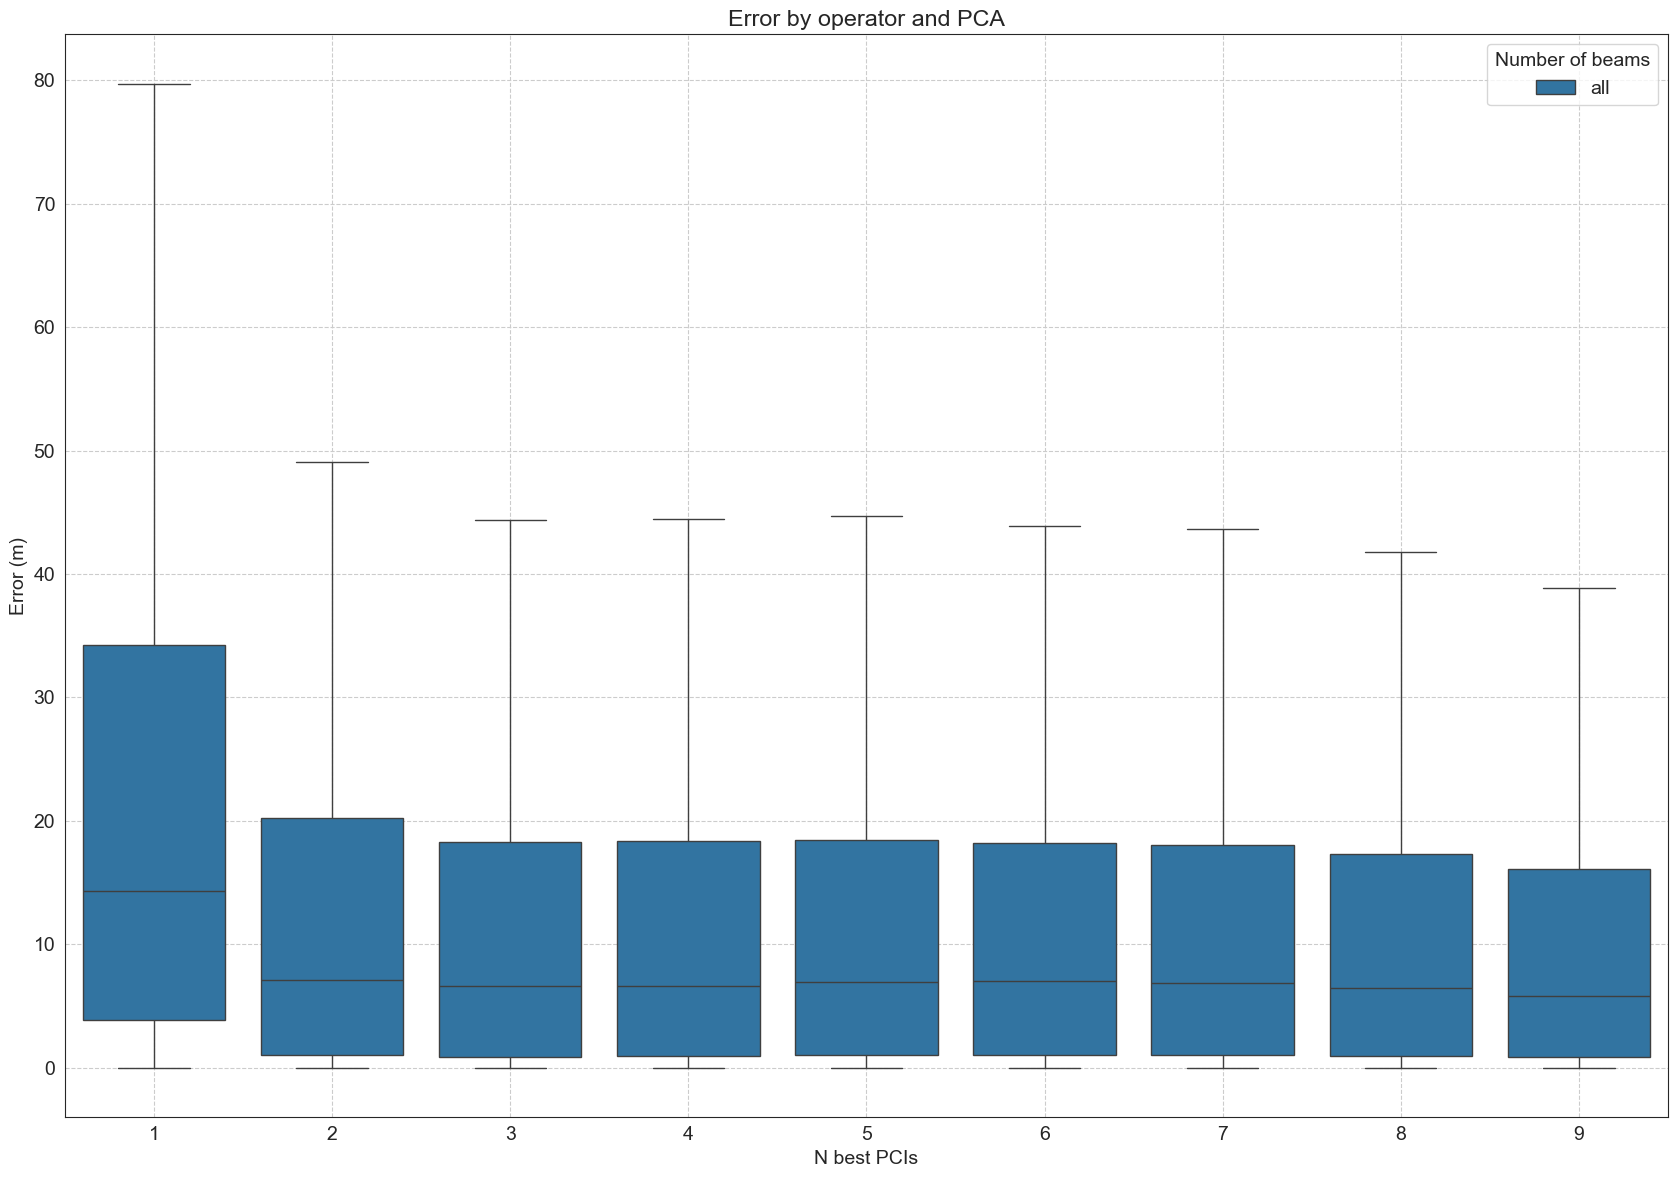

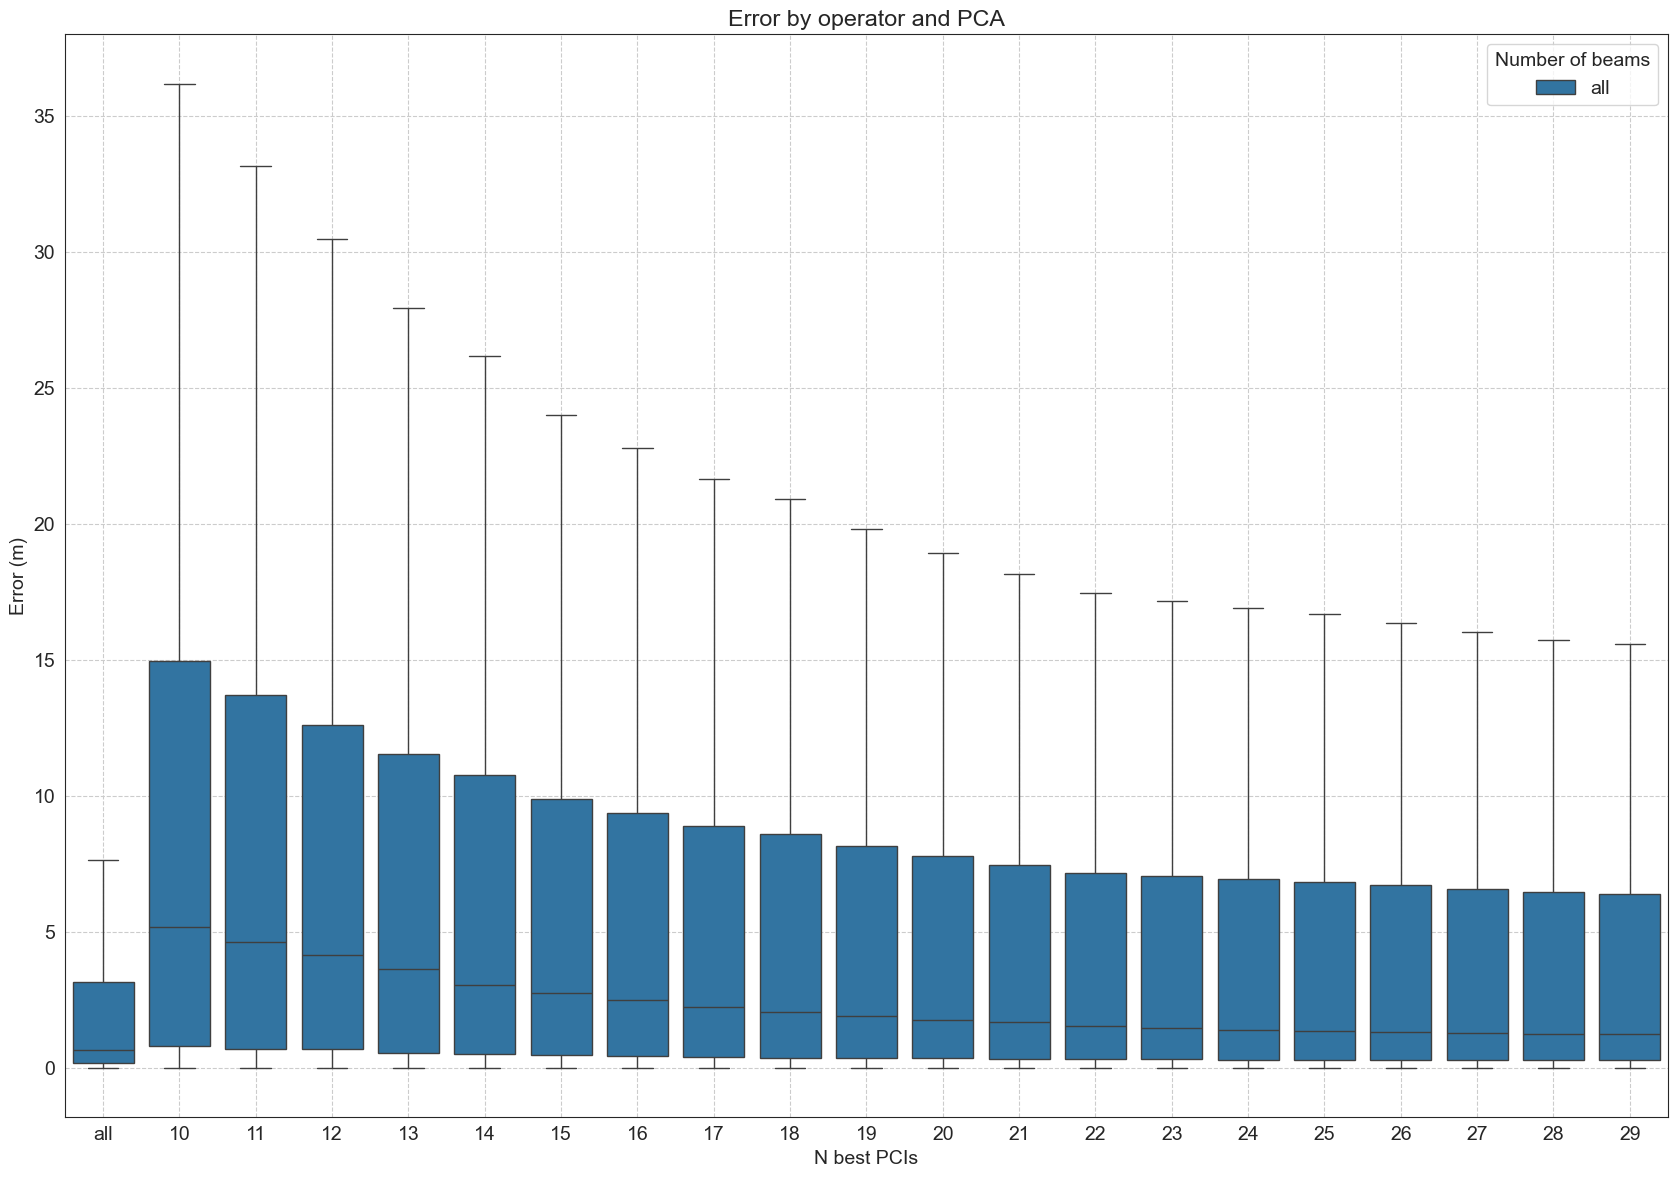

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 14})

    # baseline = df[df['n_best_pcis'] == 'all']['errors'].mean()
    #
    # data = df[df['n_best_pcis'] != 'all']

    plt.figure(figsize=(17, 12))
    sns.set_style("white")
    sns.boxplot(
        data=df,
        x='n_best_pcis',
        y='errors',
        hue='n_best_beams',
        showfliers=False,
    )

    #plt.axhline(y=baseline, color='r', linestyle='--')

    # Add labels and title
    plt.xlabel('N best PCIs')
    plt.ylabel('Error (m)')
    plt.title('Error by operator and PCA')

    plt.legend(title='Number of beams', loc='upper right')
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


#plot(df[df['n_best_pcis'] == 9])

highs = [str(i) for i in range(10, 31)] + ['all']
lows = [str(i) for i in range(1, 10)]


#plot(data_df[data_df['n_best_pcis'].isin(highs)])
#plot(data_df[data_df['n_best_pcis'].isin(lows)])

def do_plot(df):
    plot(df)
    plot(df[df['n_best_pcis'].isin(lows)])
    plot(df[df['n_best_pcis'].isin(highs)])


do_plot(data_df)

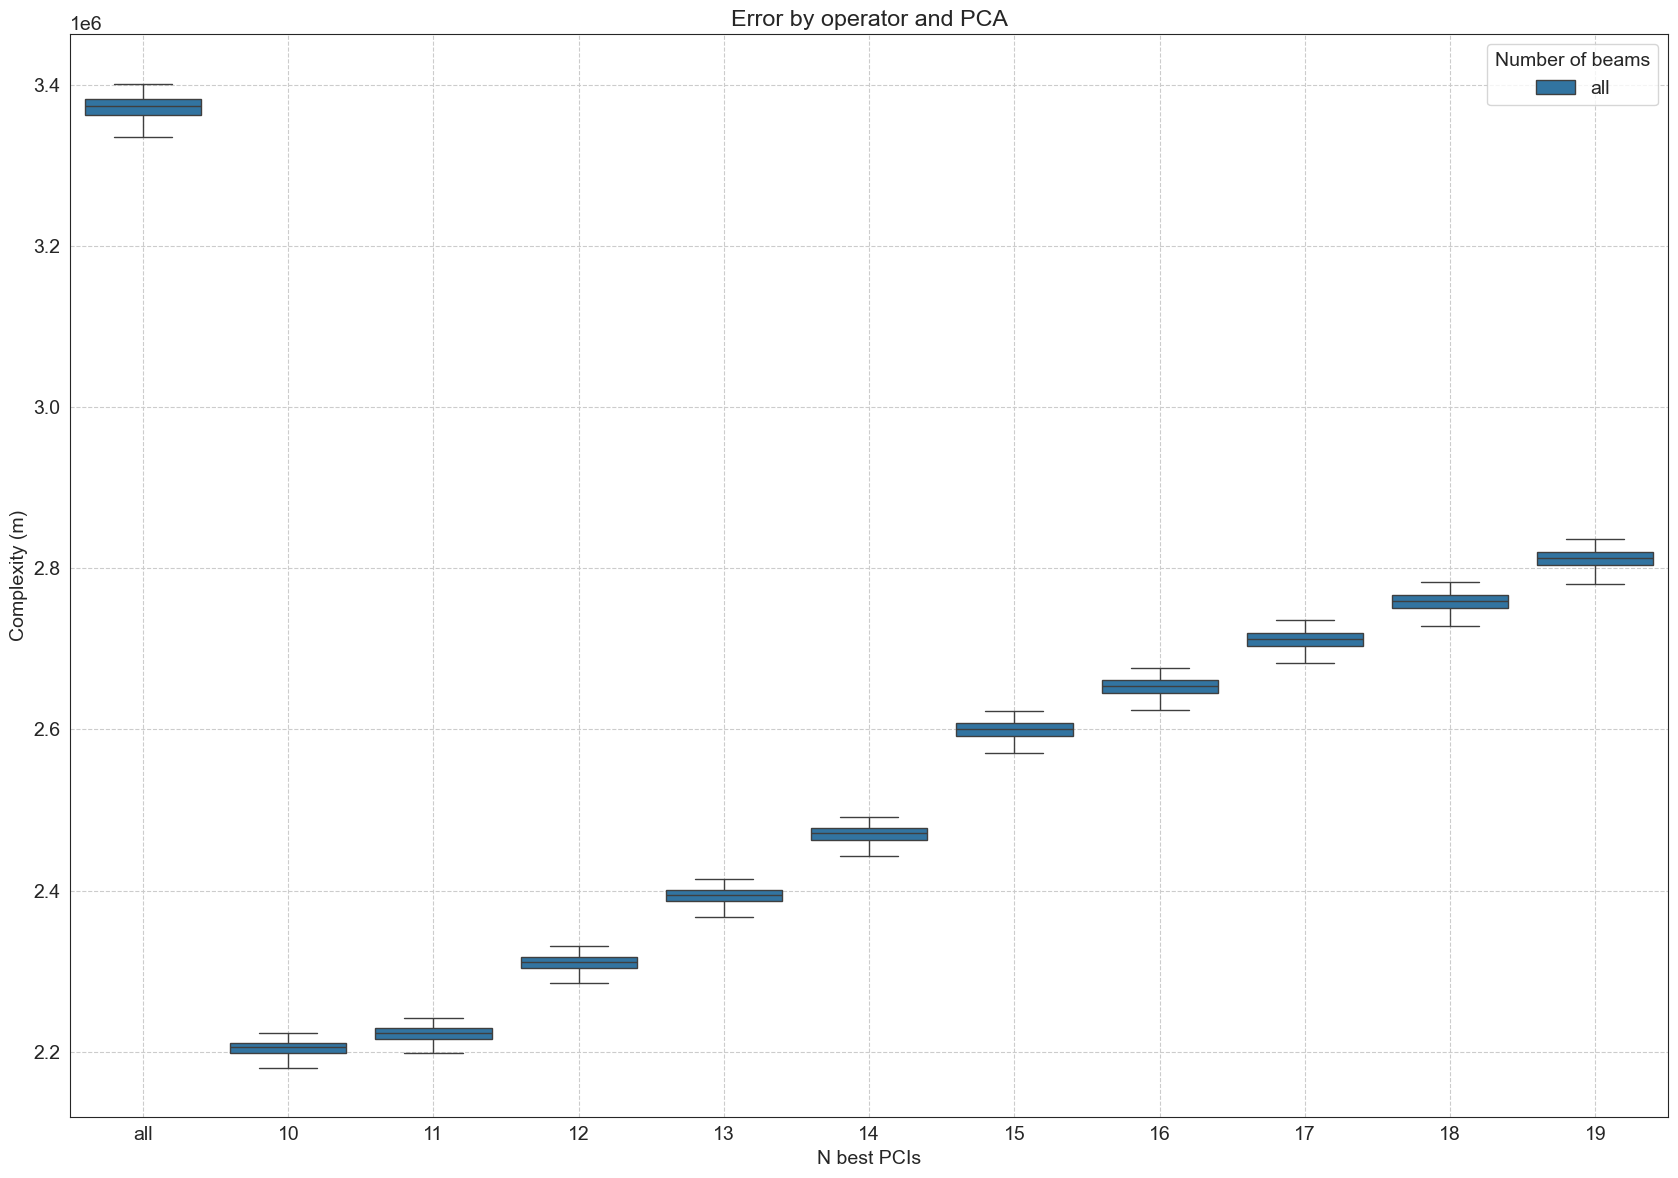

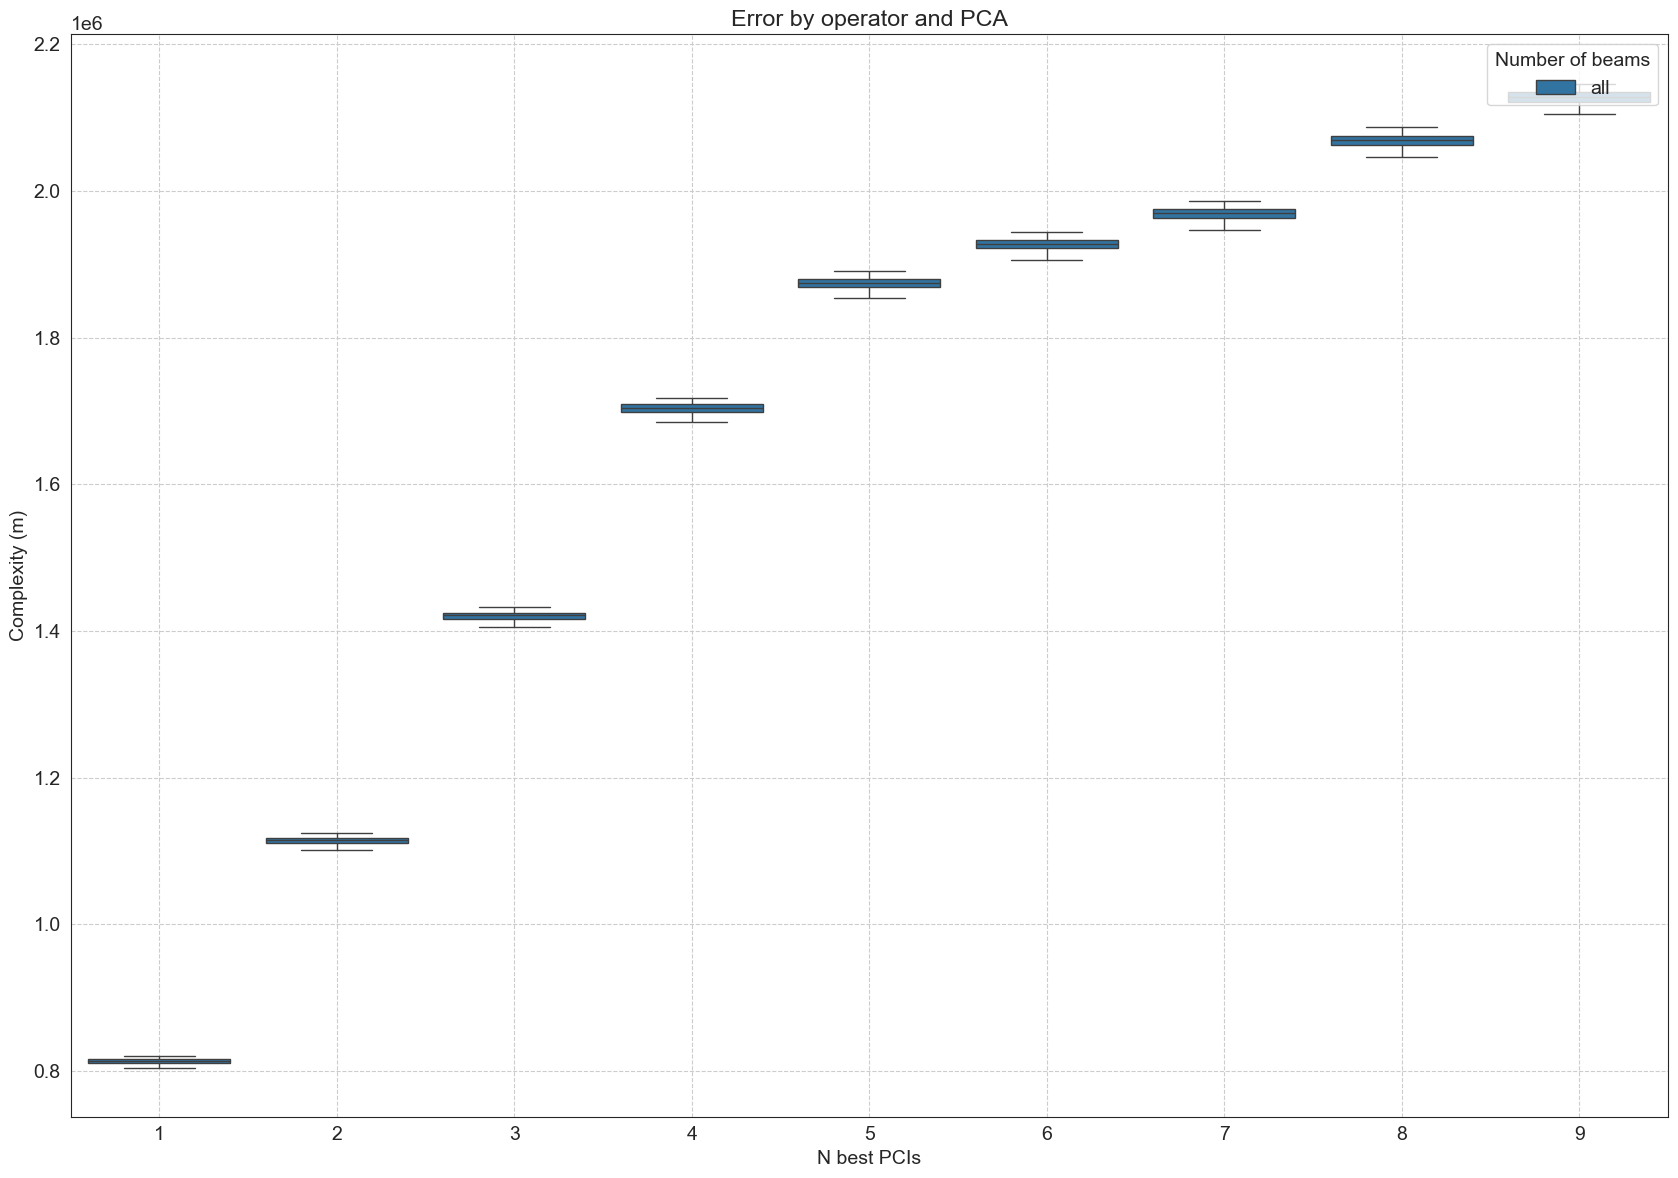

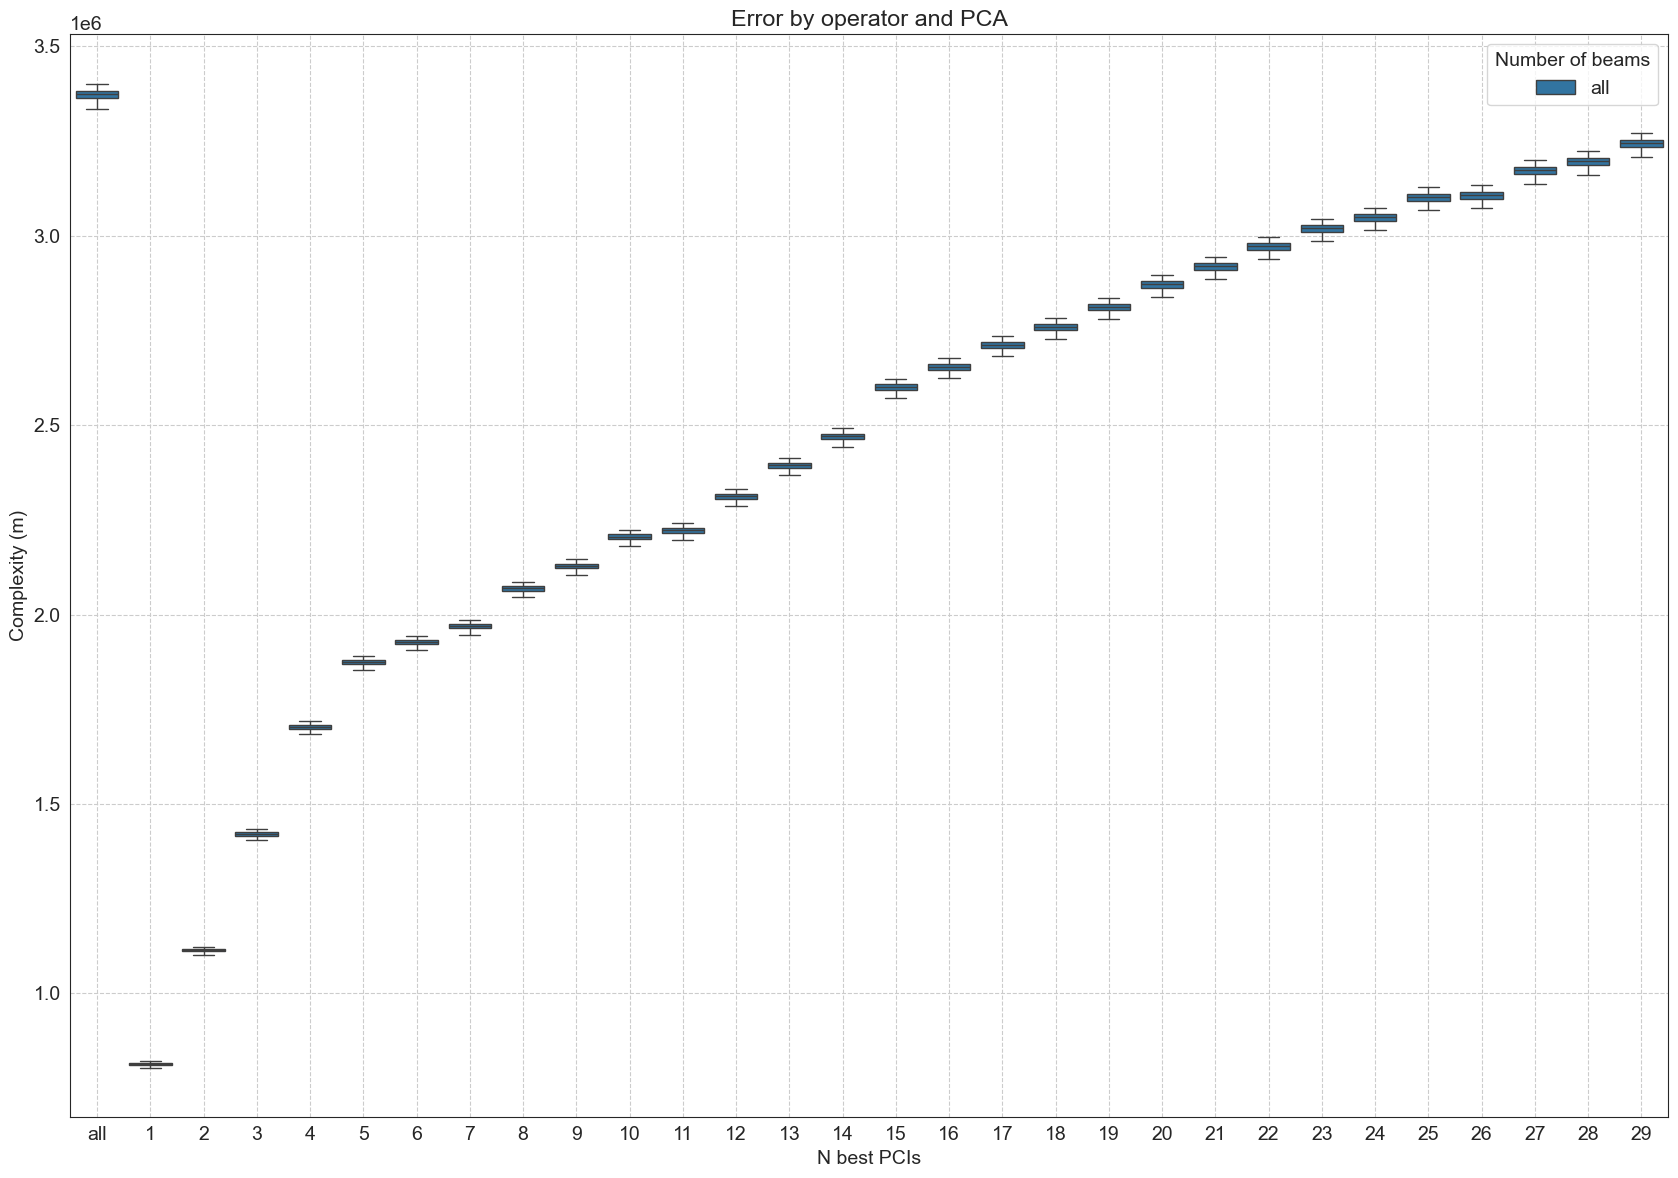

In [15]:

def plot_complexity(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 14})

    plt.figure(figsize=(17, 12))
    sns.set_style("white")
    sns.boxplot(
        data=df,
        x='n_best_pcis',
        y='complexity',
        hue='n_best_beams',
        showfliers=False,
    )

    # Add labels and title
    plt.xlabel('N best PCIs')
    plt.ylabel('Complexity (m)')
    plt.title('Error by operator and PCA')

    plt.legend(title='Number of beams', loc='upper right')
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


#plot(df[df['n_best_pcis'] == 9])

highs = [str(i) for i in range(10, 20)] + ['all']
lows = [str(i) for i in range(1, 10)]


def plottt(df):
    plot_complexity(df[df['n_best_pcis'].isin(highs)])
    plot_complexity(df[df['n_best_pcis'].isin(lows)])
    plot_complexity(df)


plottt(data_df)